In [8]:
import gymnasium as gym

env = gym.make("CartPole-v1")
#env.observation_space.n, env.action_space.n
action_size = env.action_space.n # 2 (left, right)
print("Action size: ", action_size)
#print(env.observation_space)
#print(env.observation_space.shape)
state_size = env.observation_space.shape[0] # 4 (cart position, cart velocity, pole angle, pole angular velocity)
print("State size: ", state_size)


print("Do a random sample of an action space: ", env.action_space.sample())

state, info = env.reset()
print("Current state: ", state)
state, reward, terminated, truncated, _ = env.step(0) # make it go left
print(f"Make it go left (env.step(0) - [State, Reward, Is Terminated?, Is Truncated?]] - [{state, reward, terminated, truncated}]")
state, reward, terminated, truncated, _ = env.step(1) # make it go right
print(f"Make it go right (env.step(1) - [State, Reward, Is Terminated?, Is Truncated?]] - [{state, reward, terminated, truncated}]")
state, reward, terminated, truncated, _ = env.step(0) # make it go left
print(f"Make it go left (env.step(0) - [State, Reward, Is Terminated?, Is Truncated?]] - [{state, reward, terminated, truncated}]")

Action size:  2
State size:  4
Do a random sample of an action space:  1
Current state:  [ 0.01820583 -0.03759339  0.03583863 -0.02159364]
Make it go left (env.step(0) - [State, Reward, Is Terminated?, Is Truncated?]] - [(array([ 0.01745396, -0.23321049,  0.03540675,  0.2821779 ], dtype=float32), 1.0, False, False)]
Make it go right (env.step(1) - [State, Reward, Is Terminated?, Is Truncated?]] - [(array([ 0.01278975, -0.03861099,  0.04105031,  0.000869  ], dtype=float32), 1.0, False, False)]
Make it go left (env.step(0) - [State, Reward, Is Terminated?, Is Truncated?]] - [(array([ 0.01201753, -0.23429689,  0.04106769,  0.30621597], dtype=float32), 1.0, False, False)]


Using device cuda
Training for the agent has started
Episode 100 | Reward: 16.00 | Avg(100): 21.43 | Epsilon: 0.9058
Episode 200 | Reward: 19.00 | Avg(100): 19.68 | Epsilon: 0.8205
Episode 300 | Reward: 16.00 | Avg(100): 15.82 | Epsilon: 0.7434
Episode 400 | Reward: 18.00 | Avg(100): 18.09 | Epsilon: 0.6736
Episode 500 | Reward: 14.00 | Avg(100): 20.48 | Epsilon: 0.6105
Episode 600 | Reward: 33.00 | Avg(100): 22.24 | Epsilon: 0.5533
Episode 700 | Reward: 13.00 | Avg(100): 26.78 | Epsilon: 0.5016
Episode 800 | Reward: 49.00 | Avg(100): 30.87 | Epsilon: 0.4548
Episode 900 | Reward: 101.00 | Avg(100): 47.58 | Epsilon: 0.4125
Episode 1000 | Reward: 20.00 | Avg(100): 65.63 | Epsilon: 0.3742
Episode 1100 | Reward: 166.00 | Avg(100): 86.66 | Epsilon: 0.3395
Episode 1200 | Reward: 21.00 | Avg(100): 65.84 | Epsilon: 0.3082
Episode 1300 | Reward: 19.00 | Avg(100): 60.66 | Epsilon: 0.2798
Episode 1400 | Reward: 15.00 | Avg(100): 51.11 | Epsilon: 0.2541
Episode 1500 | Reward: 21.00 | Avg(100): 56.

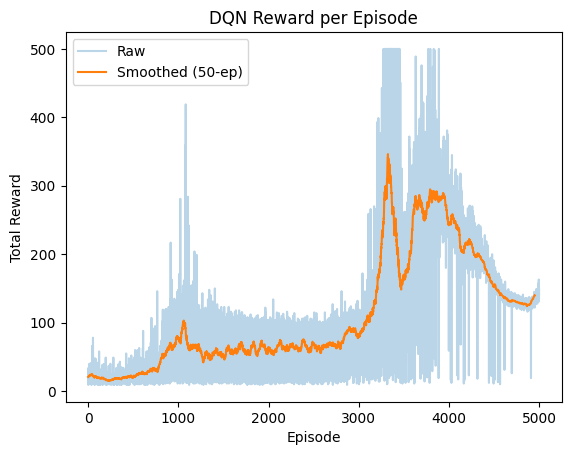

In [63]:
import random
import numpy as np
import time
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from collections import deque

import torch
import torch.nn as nn

class DQN(nn.Module):
    def __init__(self, state_size, action_size):
        super(DQN, self).__init__()
        self.l1 = nn.Linear(state_size, 64)
        self.l2 = nn.Linear(64, 64)
        self.l3 = nn.Linear(64, action_size)

    def forward(self, x):
        x = torch.relu(self.l1(x))
        x = torch.relu(self.l2(x))
        x = self.l3(x)
        return x

# HYPERPARAMETERS
MIN_EPSILON = 1e-2
MAX_EPSILON = 1.0
EPSILON = 1.0

# FIX 1: Faster, more aggressive epsilon decay so agent exploits learned policy earlier
DECAY_RATE = 0.5          # was 0.05 — now decays much faster
DECAY_STEPS = 500
MAX_EPISODES = 5000

GAMMA = 0.99
LEARNING_RATE = 1e-3      # FIX 2: Reduced from 4e-2 (0.04) — far too high for DQN
MAX_ITERATIONS = 500
BATCH_SIZE = 64           # FIX 3: Reduced from 256; smaller batches work better early on
MAX_MEMORY_BANK_SIZE = 50000
WARMUP_STEPS = 1000       # FIX 4: Don't start training until we have diverse experience
TAU = 0.005

device = 'cpu'
if torch.cuda.is_available():
    device = 'cuda'

print(f"Using device {device}")

policy_net = DQN(state_size, action_size).to(device=device)
target_net = DQN(state_size, action_size).to(device=device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()  # Target net is never trained directly

optimizer = torch.optim.AdamW(policy_net.parameters(), LEARNING_RATE)
memory = deque(maxlen=MAX_MEMORY_BANK_SIZE)


def get_next_action(current_state, epsilon):
    if random.uniform(0, 1) < epsilon:
        action = env.action_space.sample()
        return torch.tensor(action, dtype=torch.long, device=device).view(1, 1)
    else:
        with torch.no_grad():
            q_value = policy_net(current_state)
            return q_value.max(1)[1].view(1, 1)


print("Training for the agent has started")
steps_done = 0
start_time = time.time()
episode_rewards = []
epsilon = EPSILON

for eps in range(1, MAX_EPISODES + 1):
    state, _ = env.reset()
    state = torch.tensor(state, dtype=torch.float32, device=device).view(1, state_size)
    total_reward = 0

    for step in range(1, MAX_ITERATIONS + 1):
        action = get_next_action(state, epsilon)
        next_state, reward, is_terminated, is_truncated, _ = env.step(action.item())
        total_reward += reward
        reward = torch.tensor([reward], device=device)
        done = is_terminated or is_truncated

        next_state_tensor = torch.tensor(next_state, dtype=torch.float32, device=device).view(1, state_size)

        # FIX 5: Store next_state as None only in memory; don't overwrite the variable before using it
        memory_next = None if done else next_state_tensor
        memory.append((state, action, memory_next, reward, torch.tensor([done], dtype=torch.float32, device=device)))

        state = next_state_tensor  # Always valid; done check is via `break` below
        steps_done += 1

        # FIX 4: Wait for warmup before training
        if len(memory) > WARMUP_STEPS and len(memory) > BATCH_SIZE:
            transitions = random.sample(memory, BATCH_SIZE)
            batch_state, batch_action, batch_next_state, batch_reward, batch_done = zip(*transitions)

            b_s = torch.cat(batch_state)
            b_a = torch.cat(batch_action)
            b_r = torch.cat(batch_reward)
            b_d = torch.cat(batch_done)

            current_q = policy_net(b_s).gather(1, b_a)

            with torch.no_grad():
                non_final_mask = torch.tensor(
                    tuple(map(lambda s: s is not None, batch_next_state)),
                    dtype=torch.bool,
                    device=device
                )
                next_q = torch.zeros(BATCH_SIZE, device=device)
                if non_final_mask.any():
                    non_final_next_states = torch.cat([s for s in batch_next_state if s is not None])
                    next_q[non_final_mask] = target_net(non_final_next_states).max(1)[0]
                target_q = b_r + GAMMA * next_q * (1 - b_d)

            loss = F.smooth_l1_loss(current_q, target_q.unsqueeze(1))
            optimizer.zero_grad()
            loss.backward()
            # FIX 6: Use proper gradient clipping (norm-based, value of 10)
            torch.nn.utils.clip_grad_norm_(policy_net.parameters(), 10)
            optimizer.step()

        if done:
            break

    # FIX 3: Soft update once per episode, not every step
    target_net_state_dict = target_net.state_dict()
    policy_net_state_dict = policy_net.state_dict()
    for key in policy_net_state_dict:
        target_net_state_dict[key] = TAU * policy_net_state_dict[key] + (1 - TAU) * target_net_state_dict[key]
    target_net.load_state_dict(target_net_state_dict)

    # FIX 1: Epsilon now decays fast enough to exploit policy before training ends
    epsilon = MIN_EPSILON + (MAX_EPSILON - MIN_EPSILON) * np.exp(-DECAY_RATE * eps / DECAY_STEPS)

    if eps % 100 == 0:
        avg_reward = np.mean(episode_rewards[-100:])
        print(f"Episode {eps} | Reward: {total_reward:.2f} | Avg(100): {avg_reward:.2f} | Epsilon: {epsilon:.4f}")

    episode_rewards.append(total_reward)

print("Training for the agent has completed")
end_time = time.time()
print("Elapsed time: ", (end_time - start_time), "s")

# Smoothed reward plot
smoothed = np.convolve(episode_rewards, np.ones(50)/50, mode='valid')
plt.plot(episode_rewards, alpha=0.3, label='Raw')
plt.plot(smoothed, label='Smoothed (50-ep)')
plt.title("DQN Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.legend()
plt.show()

Starting testing for 10 episodes...
Test Episode 1: Reward = 179.0
Test Episode 2: Reward = 159.0
Test Episode 3: Reward = 178.0
Test Episode 4: Reward = 166.0
Test Episode 5: Reward = 175.0
Test Episode 6: Reward = 178.0
Test Episode 7: Reward = 177.0
Test Episode 8: Reward = 170.0
Test Episode 9: Reward = 173.0
Test Episode 10: Reward = 173.0

Average Test Reward: 172.8


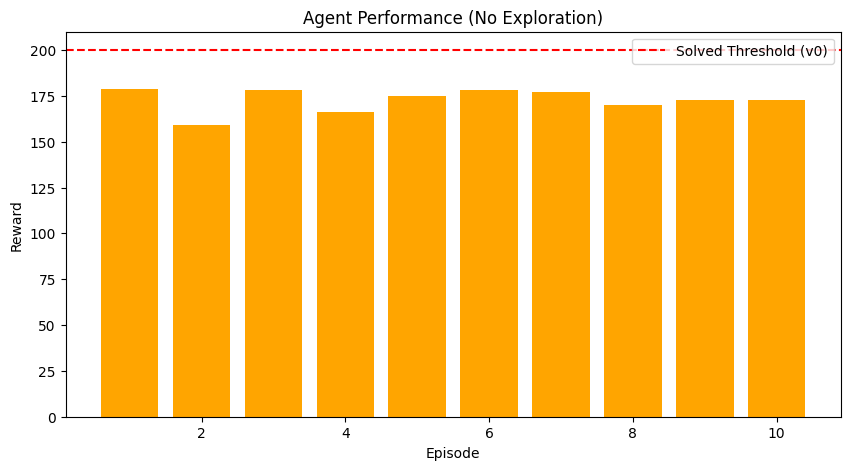

In [64]:
def test_agent(num_episodes=10, render=False):
    # If using a local machine, you can change to "human" to watch it
    env_test = gym.make("CartPole-v1", render_mode="human" if render else None)
    test_rewards = []
    print(f"Starting testing for {num_episodes} episodes...")

    policy_net.eval() # Set network to evaluation mode

    for eps in range(num_episodes):
        state, _ = env.reset()
        state = torch.tensor(state, dtype=torch.float32, device = device).unsqueeze(0)
        total_reward = 0
        done = False

        while not done:
            with torch.no_grad():
                # Always take the best action (Exploitation)
                action = policy_net(state).max(1)[1].view(1, 1)

            next_state, reward, terminated, truncated, _ = env.step(action.item())
            total_reward += reward
            done = terminated or truncated

            state = torch.tensor(next_state, dtype=torch.float32, device = device).unsqueeze(0)

        test_rewards.append(total_reward)
        print(f"Test Episode {eps+1}: Reward = {total_reward}")

    print(f"\nAverage Test Reward: {np.mean(test_rewards)}")

    # Plotting the test results
    plt.figure(figsize=(10,5))
    plt.bar(range(1, num_episodes + 1), test_rewards, color='orange')
    plt.axhline(y=200, color='r', linestyle='--', label='Solved Threshold (v0)')
    plt.title("Agent Performance (No Exploration)")
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.legend()
    plt.show()

# Run the test
test_agent(num_episodes=10)

Starting testing for 10 episodes...
Test Episode 1: Reward = 182.0
Test Episode 2: Reward = 177.0
Test Episode 3: Reward = 183.0
Test Episode 4: Reward = 176.0
Test Episode 5: Reward = 171.0
Test Episode 6: Reward = 185.0
Test Episode 7: Reward = 176.0
Test Episode 8: Reward = 179.0
Test Episode 9: Reward = 185.0
Test Episode 10: Reward = 180.0

Average Test Reward: 179.4


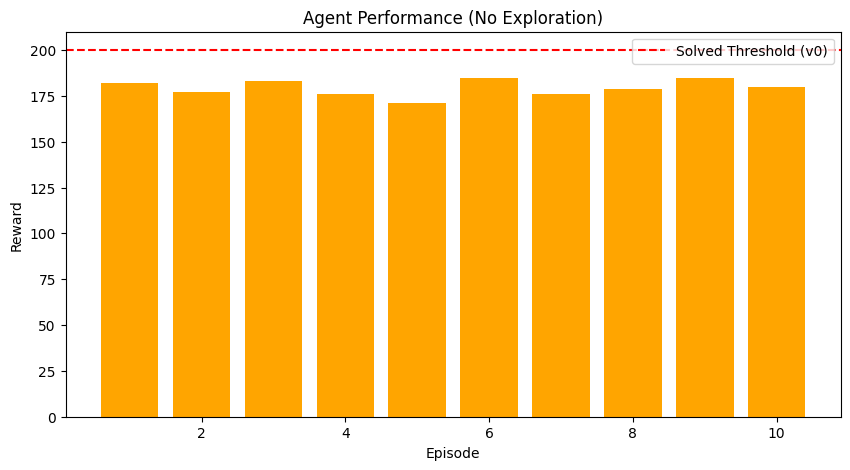

In [65]:
%matplotlib inline
test_agent(num_episodes=10, render = False)

In [58]:

state, _ = env.reset()
print("State: ", state)
state_tensor = torch.tensor(state, dtype = torch.float32).view(1, state_size).to(device)
print("state_tensor.shape ", state_tensor.shape)
q_value = policy_net(state_tensor)
print("q_value.shape: ", q_value.shape)
print("q_value: ", q_value)
print(q_value.max(1)[0])

State:  [ 0.02326597  0.04088988 -0.03355429 -0.00036276]
state_tensor.shape  torch.Size([1, 4])
q_value.shape:  torch.Size([1, 2])
q_value:  tensor([[ 0.0355, -0.1660]], device='cuda:0', grad_fn=<AddmmBackward0>)
tensor([0.0355], device='cuda:0', grad_fn=<MaxBackward0>)


In [ ]:

# trick in tuple
mem = deque(maxlen = 1000)
mem.append((1,2,3,4))
mem.append((5,6,7,8))
sample = random.sample(mem, 2)
print(sample)
a, b, c, d = zip(*sample)
print(a)
print(b)
print(c)
print(d)

[(5, 6, 7, 8), (1, 2, 3, 4)]
(5, 1)
(6, 2)
(7, 3)
(8, 4)


In [ ]:
PATH = 'cart-pole-v1-model_parameters.pth'
torch.save(policy_net.state_dict(), PATH)